## Understanding New Pedap basal format
The basal format changed with the release of `PEDAP Public Dataset - Release 4 - 2025-04-10`
This notebook analyzes the differences.

In [278]:
import os, sys, time, random
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from matplotlib import pyplot as plt

filepath = os.getcwd()
print(filepath)
sys.path.append(os.path.join(filepath, '..','..'))

from src.find_periods import find_periods
from src import pandas_helper as ph
from src import date_helper,cdf,drawing

/Users/jan/git/nudgebg/babelbetes/notebooks/understand-pedap-dataset


## Load the data

The file name changed.

|Release| File Name                          | Size   |
|-|------------------------------------|--------|
|PEDAP Public Dataset - Release 3 - 2024-09-25.zip| PEDAPTandemBASALRATECHG.txt        | 41 MB  |
|PEDAP Public Dataset - Release 4 - 2025-04-10.zip|PEDAPTandemBASALDELIVERY.txt       | 257 MB |

Let's inspect

In [279]:
old_release = 'PEDAP Public Dataset - Release 3 - 2024-09-25.zip'
new_release = 'PEDAP Public Dataset - Release 4 - 2025-04-10.zip'
study_path_old = os.path.join(filepath, '..','..', 'data','raw',old_release)
study_path_new = os.path.join(filepath, '..','..', 'data','raw',new_release)
df_basal_old = ph.get_df(os.path.join(study_path_old, 'Data Files', 'PEDAPTandemBASALRATECHG.txt'))
df_basal_new = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PEDAPTandemBASALDELIVERY.txt'))

df_cgm = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PEDAPTandemCGMDATAGXB.txt'),  usecols=['RecID', 'PtID', 'DeviceDtTm', 'CGMValue','HighLowIndicator'])
df_patient = ph.get_df(os.path.join(study_path_new, 'Data Files', 'PtRoster.txt'))

## Comparing Basal Frames

In [280]:
display(old_release)
display(df_basal_old.head())

display(new_release)
display(df_basal_new.head())

'PEDAP Public Dataset - Release 3 - 2024-09-25.zip'

,PtID,RecID,DeviceDtTm,BasalRate
0,27,3,12/28/2020 1:26:18 PM,0.300
1,27,4,12/28/2020 2:21:15 PM,0.000
2,27,5,12/28/2020 2:26:14 PM,0.300
3,27,6,12/28/2020 2:36:14 PM,0.151
4,27,7,12/28/2020 2:41:32 PM,0.148


'PEDAP Public Dataset - Release 4 - 2025-04-10.zip'

,RecID,PtID,DeviceDtTm,BasalRate
0,264605,93,11/23/2020 12:03:01 AM,0.0
1,264606,93,11/23/2020 12:08:01 AM,0.0
2,264607,93,11/23/2020 12:13:01 AM,0.0
3,264608,93,11/23/2020 12:18:01 AM,0.0
4,264609,93,11/23/2020 12:23:01 AM,0.0


In [281]:
print(f"unique CGM patient ids in old release: {len(df_basal_old.PtID.unique())}")
print(f"unique CGM patient ids in new release: {len(df_basal_new.PtID.unique())}")

unique CGM patient ids in old release: 65
unique CGM patient ids in new release: 99


We see we also have more patients. In the previous dataset we only saw 65 and assumed that this was because of the control group which didn't wear tandem devices. This was obviously wrong.

## Handle Duplicates

Drop obvious duplicates (in record id)

In [282]:
df_basal_new = df_basal_new.drop_duplicates(subset=['PtID','DeviceDtTm','BasalRate'])

In [283]:
print(f"There are {df_basal_new.duplicated(subset=['PtID','DeviceDtTm']).sum()} duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset")

print("Example of temporal duplicates:")
display(df_basal_new.loc[df_basal_new.duplicated(subset=['PtID','DeviceDtTm'], keep=False)].sort_values(by=['PtID','DeviceDtTm']).head(10))

There are 68 duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset
Example of temporal duplicates:


,RecID,PtID,DeviceDtTm,BasalRate
4013713,4358099,5,7/6/2021 2:25:26 PM,0.000
4013714,4358100,5,7/6/2021 2:25:26 PM,0.513
1801817,2109464,9,1/17/2021 8:59:38 PM,1.031
5566638,5923400,9,1/17/2021 8:59:38 PM,0.000
1801818,2109465,9,1/17/2021 9:04:38 PM,1.007
5566639,5923401,9,1/17/2021 9:04:38 PM,0.000
1801819,2109466,9,1/17/2021 9:09:38 PM,0.989
5566640,5923402,9,1/17/2021 9:09:38 PM,0.000
1802828,2110547,9,1/18/2021 6:49:39 AM,0.325
5648696,6005460,9,1/18/2021 6:49:39 AM,0.000


Text(0.5, 1.0, 'Basal Rate duplicates Min/Max')

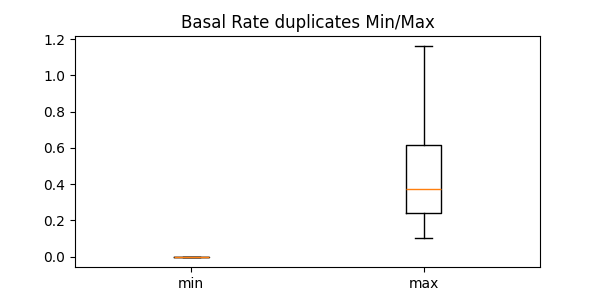

In [284]:
#compare duplicates min max values
minmax_dups = ph.get_min_max_duplicates(df_basal_new,['PtID','DeviceDtTm'],'BasalRate')
plt.figure(figsize=(6,3))
plt.boxplot([minmax_dups['min'].values,minmax_dups['max'].values],positions=[0,1],showfliers=False)
plt.xticks([0,1],['min','max'])
plt.title('Basal Rate duplicates Min/Max')

All values are either 0 or larger. We probably have to trust the non zero values. Since we are only dealing with 68 of them, this assumptions seems fair. Further investigation seems unnecessary.

In [285]:
_,_,i_drop = ph.get_duplicated_max_indexes(df_basal_new, ['PtID','DeviceDtTm'], 'BasalRate')
df_basal_new = df_basal_new.drop(index=i_drop)
print(f"After dropping duplicates, there are {df_basal_new.duplicated(subset=['PtID','DeviceDtTm']).sum()} duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset")

After dropping duplicates, there are 0 duplicated rows (only considering PtID and DeviceDtTm) in the basal dataset


## Parsing DateTimes
First, we check for datetime format:

In [286]:
# plt.figure(figsize=(6, 3)); ax=plt.gca()
# df_basal_new['DeviceDtTm'].str.len().value_counts().plot.bar(ax=ax, title='Bolus DeviceDtTm Lengths')
# plt.show()


# print(f"Example for 22 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 22].iloc[0]}")  
# print(f"Example for 21 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 21].iloc[0]}")
# print(f"Example for 20 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 20].iloc[0]}")
# print(f"Example for 19 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 19].iloc[0]}")
# print(f"Example for 10 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 10].iloc[0]}")
# print(f"Example for 9 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 9].iloc[0]}")
# print(f"Example for 8 characters: {df_basal_new.DeviceDtTm[df_basal_new['DeviceDtTm'].str.len() == 8].iloc[0]}")

# # print()
# # temp = df_basal.index[df_basal['DeviceDtTm'].str.len() == 8][0]
# # print(f"Example for midnight datetime: ")
# # display(df_basal.loc[temp-2:temp+2])

As before we have dates with missing time component. Again, we assume these are midnight.

In [287]:
df_cgm['datetime'] = date_helper.parse_flair_dates(df_cgm['DeviceDtTm'])
df_basal_new['datetime'] = date_helper.parse_flair_dates(df_basal_new['DeviceDtTm'])
df_basal_old['datetime'] = date_helper.parse_flair_dates(df_basal_old['DeviceDtTm'])

In [288]:
df_cgm['date'] = df_cgm['datetime'].dt.date
df_basal_new['date'] = df_basal_new['datetime'].dt.date
df_basal_old['date'] = df_basal_old['datetime'].dt.date

## CLC vs SC groups
Previously we assumed that all SC patients must be dropped. 
This is wrong. SC patients can use the Tandem control iq device after the first 13 weeks of data.

In [289]:
treatment_groups = df_patient.groupby('TrtGroup')
clc_ids = treatment_groups.get_group('CLC').PtID.unique()
sc_ids = treatment_groups.get_group('SC').PtID.unique()

clc_w_basal = np.intersect1d(df_basal_new.PtID.unique(),clc_ids)
sc_w_basal = np.intersect1d(df_basal_new.PtID.unique(),sc_ids)

print(f"Of all {len(clc_ids)} CLC patient IDs, {len(clc_w_basal)} have basal data.")
print(f"Of all {len(sc_ids)} SC patient IDs, {len(sc_w_basal)} have basal data.")

Of all 68 CLC patient IDs, 66 have basal data.
Of all 34 SC patient IDs, 33 have basal data.


Both groups have basal data.

### Get daily basal counts

In [290]:
#merge treatment group to df_basal_new
df_basal_new = pd.merge(df_basal_new, df_patient[['PtID','TrtGroup']], on='PtID', how='inner')

In [291]:
#get number of days and daily events
temp = df_basal_new.groupby(['TrtGroup','PtID','date']).size().reset_index(name='daily_basal_count').groupby(['TrtGroup']).daily_basal_count.mean()
print(f"Average number of basal rates per day for CLC patients: {temp['CLC']:.0f}")
print(f"Average number of basal rates per day for SC patients: {temp['SC']:.0f}")

temp = df_basal_new.groupby(['TrtGroup','PtID']).date.nunique().reset_index(name='n_days').groupby(['TrtGroup']).n_days.mean()
print(f"Average number of days with basal data for CLC patients: {temp['CLC']:.0f}")
print(f"Average number of days with basal data for SC patients: {temp['SC']:.0f}")


Average number of basal rates per day for CLC patients: 287
Average number of basal rates per day for SC patients: 286
Average number of days with basal data for CLC patients: 274
Average number of days with basal data for SC patients: 173


The CLC group has about 13 weeks more of data which makes sense. The number of events are the same.
From this we can conclude that we only see tandem data when the patient was wearing and using the CLC algorithm.
The data does not seem to contain data from the first 13 weeks of data for SC patients.

## Compare Basal from old and new files

Random patient: 100


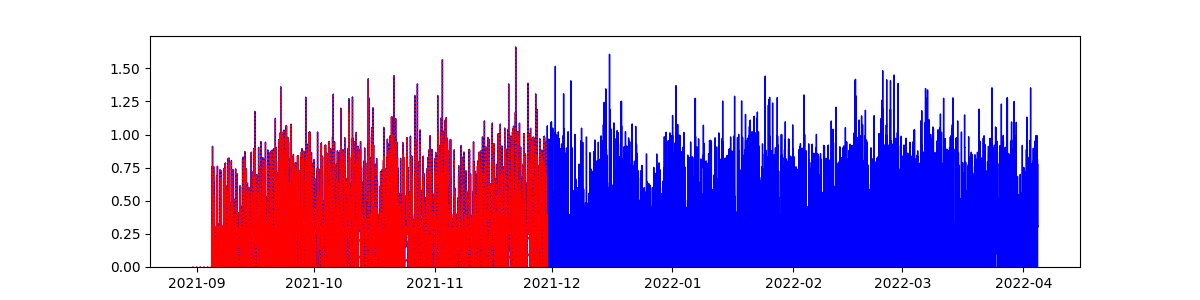

In [292]:
random_patient= np.random.choice(np.intersect1d(df_basal_new.PtID.unique(),df_basal_old.PtID.unique()),1)[0]
print(f"Random patient: {random_patient}")

df_basal_new_patient = df_basal_new[df_basal_new.PtID == random_patient]
df_basal_old_patient = df_basal_old[df_basal_old.PtID == random_patient]

plt.figure(figsize=(12, 3));ax=plt.gca()
#plt.scatter(df_basal_new_patient.date.unique(), [0]*len(df_basal_new_patient.date.unique()), label='New Release', color='blue')
#plt.scatter(df_basal_old_patient.date.unique(), [1]*len(df_basal_old_patient.date.unique()), label='Old Release', color='orange')
#plt.ylim(-0.5, 1.5)
drawing.drawAbsoluteBasalRates(ax,df_basal_new_patient.datetime.values, df_basal_new_patient.BasalRate.values,edgecolor='blue')
drawing.drawAbsoluteBasalRates(ax,df_basal_old_patient.datetime.values, df_basal_old_patient.BasalRate.values,edgecolor='red',alpha=1,linestyle=':')
#plt.xlim(start-timedelta(hours=12), start+timedelta(hours=36))


In [ ]:
results = []

for patient_id in np.intersect1d(df_basal_new.PtID.unique(), df_basal_old.PtID.unique()):
    df_basal_new_patient = df_basal_new[df_basal_new.PtID == patient_id]
    df_basal_old_patient = df_basal_old[df_basal_old.PtID == patient_id]

    df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

    temp = pd.merge(
        df_basal_old_patient[['datetime', 'BasalRate']],
        df_basal_new_patient_inters[['datetime', 'BasalRate']],
        on='datetime',
        how='outer',
        suffixes=('_old', '_new')
    ).sort_values(by='datetime')

    diff_stats = (temp.BasalRate_new - temp.BasalRate_old).describe()
    results.append({
        'PtID': patient_id,
        'old_length': len(df_basal_old_patient),
        'new_length': len(df_basal_new_patient),
        'intersection_length': len(df_basal_new_patient_inters),
        'mean_diff': diff_stats['mean'],
        'std_diff': diff_stats['std'],
        'min_diff': diff_stats['min'],
        'max_diff': diff_stats['max']
    })

results_df = pd.DataFrame(results)
display(results_df)

results_df.mean_diff.describe()


,PtID,old_length,new_length,intersection_length,mean_diff,std_diff,min_diff,max_diff
0,3,7850,77084,23124,-6.767880e-10,8.279298e-09,-5.531311e-08,3.051758e-08
1,4,5024,98328,28326,-6.417405e-10,5.010324e-09,-2.956390e-08,2.956390e-08
2,5,9399,60907,26028,-7.220886e-10,7.351061e-09,-2.956390e-08,2.908707e-08
3,8,25497,102585,27963,3.486401e-10,6.128071e-09,-4.386902e-08,5.912781e-08
4,9,9688,108220,27649,1.183882e-10,1.076440e-08,-5.817413e-08,5.817413e-08
...,...,...,...,...,...,...,...,...
60,102,6392,81100,26458,-1.049153e-09,5.186310e-09,-2.765655e-08,2.956390e-08
61,103,11465,100899,27853,-2.211211e-10,9.702652e-09,-5.912781e-08,5.626678e-08
62,106,23179,73716,26653,5.682170e-10,8.354518e-09,-5.912781e-08,5.912781e-08
63,107,7851,74895,23932,-1.546182e-09,9.751617e-09,-5.340576e-08,5.245209e-08


count    6.500000e+01
mean     7.563825e-07
std      5.615544e-06
min     -5.661281e-08
25%     -9.682473e-10
50%     -5.139772e-10
75%     -2.371724e-10
max      4.515223e-05
Name: mean_diff, dtype: float64

We see that for patient 3 for example the number of events of the intersection is much larger. Still on visual inspection everything looks okay. Whats going on?

The number of basal rates for patient 3 in the old release is 7850 and in the intersection of new release is 23124.


,PtID,RecID,DeviceDtTm,BasalRate,datetime,date
825306,3,872351,9/28/2021 11:59:13 AM,0.150,2021-09-28 11:59:13,2021-09-28
825307,3,872352,9/28/2021 12:01:25 PM,0.000,2021-09-28 12:01:25,2021-09-28
825308,3,872353,9/28/2021 12:05:22 PM,0.556,2021-09-28 12:05:22,2021-09-28
825309,3,872354,9/28/2021 12:10:22 PM,0.150,2021-09-28 12:10:22,2021-09-28
825310,3,872355,9/28/2021 12:38:32 PM,0.000,2021-09-28 12:38:32,2021-09-28
825311,3,872356,9/28/2021 12:48:56 PM,0.000,2021-09-28 12:48:56,2021-09-28
825312,3,872357,9/28/2021 1:48:44 PM,0.150,2021-09-28 13:48:44,2021-09-28
825313,3,872358,9/28/2021 1:58:34 PM,0.000,2021-09-28 13:58:34,2021-09-28


,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup,diff
3307912,3944848,3,9/28/2021 11:59:13 AM,0.150,2021-09-28 11:59:13,2021-09-28,CLC,-0.060
3307913,3944849,3,9/28/2021 12:04:13 PM,0.000,2021-09-28 12:04:13,2021-09-28,CLC,-0.299
3307914,3944850,3,9/28/2021 12:05:22 PM,0.556,2021-09-28 12:05:22,2021-09-28,CLC,0.376
3307915,3944851,3,9/28/2021 12:10:22 PM,0.150,2021-09-28 12:10:22,2021-09-28,CLC,-0.030
3307916,3944852,3,9/28/2021 12:15:21 PM,0.150,2021-09-28 12:15:21,2021-09-28,CLC,-0.216
3307917,3944853,3,9/28/2021 12:20:21 PM,0.150,2021-09-28 12:20:21,2021-09-28,CLC,-0.030
3307918,3944854,3,9/28/2021 12:25:19 PM,0.150,2021-09-28 12:25:19,2021-09-28,CLC,-0.387
3307919,3944855,3,9/28/2021 12:30:19 PM,0.150,2021-09-28 12:30:19,2021-09-28,CLC,-0.436


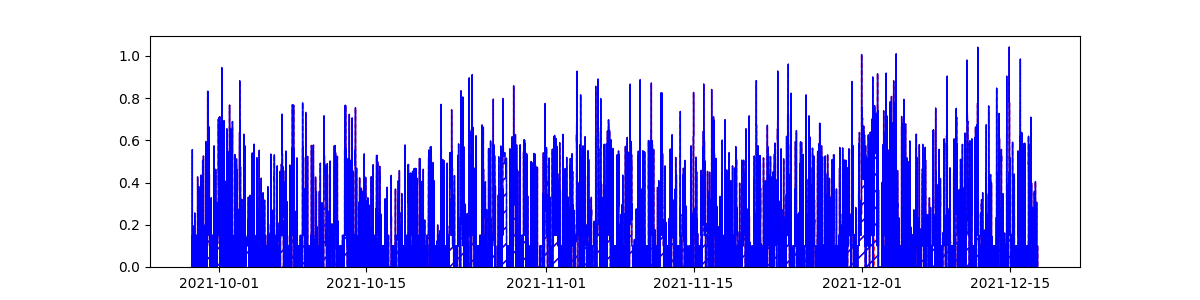

In [307]:
random_patient= 3

df_basal_new_patient = df_basal_new[df_basal_new.PtID == random_patient]
df_basal_old_patient = df_basal_old[df_basal_old.PtID == random_patient]
df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

print(f"The number of basal rates for patient {random_patient} in the old release is {len(df_basal_old_patient)} and in the intersection of new release is {len(df_basal_new_patient_inters)}.")


plt.figure(figsize=(12, 3));ax=plt.gca()    
drawing.drawAbsoluteBasalRates(ax,df_basal_old_patient.datetime.values, df_basal_old_patient.BasalRate.values,edgecolor='red',alpha=1,linestyle='--')
drawing.drawAbsoluteBasalRates(ax,df_basal_new_patient_inters.datetime.values, df_basal_new_patient_inters.BasalRate.values,edgecolor='blue')

display(df_basal_old_patient.sort_values('datetime').head(8))
display(df_basal_new_patient_inters.sort_values('datetime').head(8))

It looks like the same basal rates are reported several times. 

In [311]:
def drop_repetitive_values(df, column):
    """
    Drops rows with repetitive values in the specified column, keeping only rows where the value changes.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column to check for repetitive values.

    Returns:
        pd.DataFrame: A DataFrame with repetitive values dropped.
    """
    df = df.sort_values('datetime')  # Ensure the DataFrame is sorted by datetime
    df['diff'] = df[column].diff()  # Calculate the difference between consecutive rows
    result = df.loc[df['diff'] != 0].drop(columns=['diff'])  # Keep rows where the value changes
    return result

display(df_basal_new_patient_inters.sort_values('datetime').head(8))
display(drop_repetitive_values(df_basal_new_patient_inters, 'BasalRate').sort_values('datetime').head(8))

#compare
df_basal_new_patient_drop_repetitive = drop_repetitive_values(df_basal_new_patient_inters, 'BasalRate')
df_basal_new_patient_inters_drop_repetitive = drop_repetitive_values(df_basal_new_patient_inters, 'BasalRate')
print(f"Lengths are: {len(df_basal_new_patient_drop_repetitive)} and {len(df_basal_new_patient_inters_drop_repetitive)}")

,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup,diff
3307912,3944848,3,9/28/2021 11:59:13 AM,0.150,2021-09-28 11:59:13,2021-09-28,CLC,-0.060
3307913,3944849,3,9/28/2021 12:04:13 PM,0.000,2021-09-28 12:04:13,2021-09-28,CLC,-0.299
3307914,3944850,3,9/28/2021 12:05:22 PM,0.556,2021-09-28 12:05:22,2021-09-28,CLC,0.376
3307915,3944851,3,9/28/2021 12:10:22 PM,0.150,2021-09-28 12:10:22,2021-09-28,CLC,-0.030
3307916,3944852,3,9/28/2021 12:15:21 PM,0.150,2021-09-28 12:15:21,2021-09-28,CLC,-0.216
3307917,3944853,3,9/28/2021 12:20:21 PM,0.150,2021-09-28 12:20:21,2021-09-28,CLC,-0.030
3307918,3944854,3,9/28/2021 12:25:19 PM,0.150,2021-09-28 12:25:19,2021-09-28,CLC,-0.387
3307919,3944855,3,9/28/2021 12:30:19 PM,0.150,2021-09-28 12:30:19,2021-09-28,CLC,-0.436


,RecID,PtID,DeviceDtTm,BasalRate,datetime,date,TrtGroup
3307912,3944848,3,9/28/2021 11:59:13 AM,0.150,2021-09-28 11:59:13,2021-09-28,CLC
3307913,3944849,3,9/28/2021 12:04:13 PM,0.000,2021-09-28 12:04:13,2021-09-28,CLC
3307914,3944850,3,9/28/2021 12:05:22 PM,0.556,2021-09-28 12:05:22,2021-09-28,CLC
3307915,3944851,3,9/28/2021 12:10:22 PM,0.150,2021-09-28 12:10:22,2021-09-28,CLC
3307921,3944857,3,9/28/2021 12:40:18 PM,0.000,2021-09-28 12:40:18,2021-09-28,CLC
3308395,3945368,3,9/28/2021 1:48:44 PM,0.150,2021-09-28 13:48:44,2021-09-28,CLC
3308397,3945370,3,9/28/2021 1:58:44 PM,0.000,2021-09-28 13:58:44,2021-09-28,CLC
3308398,3945371,3,9/28/2021 2:00:45 PM,0.120,2021-09-28 14:00:45,2021-09-28,CLC


Lengths are: 7635 and 7635


In [312]:
pd.testing.assert_frame_equal(df_basal_new_patient_drop_repetitive[['PtID','datetime','BasalRate']], 
                              df_basal_new_patient_inters_drop_repetitive[['PtID','datetime','BasalRate']], 
                              check_dtype=False, check_exact=False)

In [ ]:
results = []

for patient_id in np.intersect1d(df_basal_new.PtID.unique(), df_basal_old.PtID.unique()):
    
    df_basal_old_patient = drop_repetitive_values(df_basal_old[df_basal_old.PtID == patient_id], 'BasalRate')
    df_basal_new_patient = drop_repetitive_values(df_basal_new[df_basal_new.PtID == patient_id], 'BasalRate')
    df_basal_new_patient_inters = df_basal_new_patient.loc[df_basal_new_patient.datetime.between(df_basal_old_patient.datetime.min(),
                                                                                                 df_basal_old_patient.datetime.max(),
                                                                                                 inclusive='both')]

    temp = pd.merge(
        df_basal_old_patient[['datetime', 'BasalRate']],
        df_basal_new_patient_inters[['datetime', 'BasalRate']],
        on='datetime',
        how='outer',
        suffixes=('_old', '_new')
    ).sort_values(by='datetime')

    diff_stats = (temp.BasalRate_new - temp.BasalRate_old).describe()
    results.append({
        'PtID': patient_id,
        'old_length': len(df_basal_old_patient),
        'new_length': len(df_basal_new_patient),
        'intersection_length': len(df_basal_new_patient_inters),
        'mean_diff': diff_stats['mean'],
        'std_diff': diff_stats['std'],
        'min_diff': diff_stats['min'],
        'max_diff': diff_stats['max']
    })

results_df = pd.DataFrame(results)
display(results_df)

results_df.mean_diff.describe()


,PtID,old_length,new_length,intersection_length,mean_diff,std_diff,min_diff,max_diff
0,3,7643,77084,7635,-6.600133e-10,8.378883e-09,-5.531311e-08,3.051758e-08
1,4,4758,98328,4940,-6.047898e-10,5.139192e-09,-2.956390e-08,2.956390e-08
2,5,9323,60907,9320,-7.168659e-10,7.378013e-09,-2.956390e-08,2.908707e-08
3,8,9986,102585,9985,8.230952e-11,8.895916e-09,-4.386902e-08,5.912781e-08
4,9,9632,108220,11517,1.267753e-10,1.081888e-08,-5.817413e-08,5.817413e-08
...,...,...,...,...,...,...,...,...
60,102,6214,81100,6205,-1.036430e-09,5.254701e-09,-2.765655e-08,2.956390e-08
61,103,11416,100899,11411,-2.188273e-10,9.714104e-09,-5.912781e-08,5.626678e-08
62,106,11075,73716,11064,2.450859e-10,1.015161e-08,-5.912781e-08,5.912781e-08
63,107,7801,74895,7794,-1.546222e-09,9.779669e-09,-5.340576e-08,5.245209e-08


count    6.500000e+01
mean     1.332956e-07
std      1.075882e-06
min     -5.673222e-08
25%     -9.698807e-10
50%     -5.114603e-10
75%     -2.352890e-10
max      8.673098e-06
Name: mean_diff, dtype: float64